# Work with images

- Data set: https://www.repository.cam.ac.uk/items/b6a97f0c-3b9b-40ad-8f18-3d121eef1459
- Data set location: ./MIASDBv1.21

In [1]:
local = False
if local:
    !uv add pypnm torch numpy matplotlib
else:
    !pip install pypnm torch numpy matplotlib opencv-python

In [2]:
import os
import random
import numpy as np
import pypnm
import matplotlib.pyplot as plt
from multiprocessing import Pool
import shutil
import cv2
import pandas as pd
import albumentations as A
import tensorflow as tf

# Data Preparation

In [3]:
if local:
    ruta_carpeta = "./MIASDBv1.21"
else: 
    ruta_zip_drive = "/content/drive/MyDrive/6 semestre/IA/miasdbv1.21.zip"
    ruta_local_mv = "/content/mias_local"
    ruta_carpeta = os.path.join(ruta_local_mv, "MIASDBv1.21")
    
    if not os.path.exists(ruta_local_mv) or not os.listdir(ruta_local_mv):
        print("Copiando y descomprimiendo dataset...")
        os.makedirs(ruta_local_mv, exist_ok=True)
        os.system(f'cp "{ruta_zip_drive}" /content/temp.zip')
        os.system(f'unzip -q /content/temp.zip -d "{ruta_local_mv}"')
        os.system('rm /content/temp.zip')
        
    if not os.path.exists(ruta_carpeta):
        ruta_carpeta = ruta_local_mv


imagenes = [f for f in os.listdir(ruta_carpeta) if f.endswith('.pgm')]
random.seed(42)
random.shuffle(imagenes)


len_imagenes = len(imagenes)
limite_train = int(len_imagenes * 0.70)
limite_val = int(len_imagenes * 0.85)
files_train = imagenes[:limite_train]
files_val = imagenes[limite_train:limite_val]
files_test = imagenes[limite_val:]

In [4]:
tamaños_detectados = {}

for archivo in imagenes:
    ruta_completa = os.path.join(ruta_carpeta, archivo)
    img = cv2.imread(ruta_completa, cv2.IMREAD_UNCHANGED)
    if img is not None:
        dimensiones = img.shape
        if dimensiones in tamaños_detectados:
            tamaños_detectados[dimensiones] += 1
        else:
            tamaños_detectados[dimensiones] = 1

for dim, conteo in tamaños_detectados.items():
    print(f"Dimensiones {dim}: {conteo} imágenes")

Dimensiones (2048, 4320): 101 imágenes
Dimensiones (2600, 4320): 149 imágenes
Dimensiones (4000, 5200): 24 imágenes
Dimensiones (1600, 4320): 48 imágenes


In [5]:
mias_truth_data = """
mdb001lm G CIRC B 1815 1116 790
mdb002rl G CIRC B 3091 1262 277
mdb00311 D NORM
mdb004rl D NORM
mdb005ll F CIRC B 647 1163 122
mdb006rl F NORM
mdb00711 G NORM
mdb008rl G NORM
mdb009ll F NORM
mdb010rm F CIRC B 2509 975 135
mdb011ll F NORM
mdb012rl F CIRC B 2378 1467 162
mdb013ll G MISC B 1574 1923 127
mdb014rl G NORM
mdb015lm G CIRC B 3571 1359 275
mdb016rm G NORM
mdb017ls G CIRC B 2407 943 192
mdb018rs G NORM
mdb019ll G CIRC B 2021 1864 197
mdb020rl G NORM
mdb021ll G CIRC B 612 1224 197
mdb022rm G NORM
mdb023ll G CIRC M 2837 1405 117
mdb024rl G NORM
mdb025ll F CIRC B 1886 1948 318
mdb026rl F NORM
mdb027ll F NORM
mdb028rl F CIRC M 2953 1999 224
mdb029ll G NORM
mdb030rm G MISC B 1505 1785 174
mdb031ll G NORM
mdb032rl G MISC B 1243 1798 267
mdb033ls D NORM
mdb034rs D NORM
mdb035ls D NORM
mdb036rs D NORM
mdb037ls D NORM
mdb038rs D NORM
mdb039ls D NORM
mdb040rs D NORM
mdb041ll G NORM
mdb042rl G NORM
mdb043ls G NORM
mdb044rs G NORM
mdb045lm G NORM
mdb046rm G NORM
mdb047lm G NORM
mdb048rm G NORM
mdb049ll G NORM
mdb050rl G NORM
mdb051ll G NORM
mdb052rm G NORM
mdb053ls D NORM
mdb054rs D NORM
mdb055lm G NORM
mdb056rm G NORM
mdb057ll D NORM
mdb058rl D MISC M 2774 2079 110
mdb059ls F CIRC B
mdb060rs F NORM
mdb061ls D NORM
mdb062rs D NORM
mdb063lm D MISC B 1967 133 1163
mdb064rm D NORM
mdb065lm D NORM
mdb066rm D NORM
mdb067ll D NORM
mdb068rl D NORM
mdb069ll F CIRC B 1739 177 1101
mdb070rl F NORM
mdb071lm G NORM
mdb072rm G ASYM M 2140 115  2011
mdb073ls G NORM
mdb074rs G NORM
mdb075lm F ASYM M 2982 92 850
mdb076rm F NORM
mdb077ll F NORM
mdb078rl F NORM
mdb079lm F NORM
mdb080rm F CIRC B 3615 1344 81
mdb081ll G ASYM B 2007 1220 525
mdb082rl G NORM
mdb08311 G ASYM B 891 1428 152
mdb084rl G NORM
mdb085lm G NORM
mdb086rm G NORM
mdb087lm F NORM
mdb088rm F NORM
mdb089lm G NORM
mdb090rm G ASYM M 2021 1035 198
mdb091lm F CIRC B 2090 1696 82
mdb092rm F ASYM M 1562 1382 175
mdb093lm G NORM
mdb094rm G NORM
mdb095ll F ASYM M 2181 1118 116
mdb096rl F NORM
mdb09711 F ASYM B 1302 1702 137
mdb098rl F NORM
mdb099lm D ASYM B 1473 1834 93
mdb100rm D NORM
mdb101lm D NORM
mdb102rm D ASYM M 2369 1412 152
mdb103lm D NORM
mdb104rm D ASYM B 2751 1645 203
mdb105ll D ASYM M 1229 1318 392
mdb106rl D NORM
mdb107ll D ASYM B 2597 1653 446
mdb108rl D NORM
mdb109ll D NORM
mdb110rl D ASYM M 2502 2590 205
mdb111ll D ASYM M 2414 1275 428
mdb112rl D NORM
mdb113ls G NORM
mdb114rs G NORM
mdb115ll G ARCH M 2240 1096 468
mdb116rl G NORM
mdb117ll G ARCH M 2417 1175 337
mdb118rl G NORM
mdb119ll G NORM
mdb120rl G ARCH M 3162 1659 319
mdb121ll G ARCH B 1849 1221 348
mdb122rl G NORM
mdb123lm G NORM
mdb124rm G ARCH M 1729 1609 135
mdb125ll D ARCH M 2322 2054 242
mdb126rl D ARCH B 2015 2585 93
mdb127lm G ARCH B 2317 1069 194
mdb128rm G NORM
mdb129ll D NORM
mdb130rl D ARCH M 2002 2469 112
mdb131lx F NORM
mdb132rx F CIRC B 1499 3043 211
mdb133lx F NORM
mdb134rx F MISC M 1736 2173 199
mdb135lx F NORM
mdb136rx F NORM
mdb137ll D NORM
mdb138rl D NORM
mdb139lx F NORM
mdb140rx F NORM
mdb141lx F CIRC M 3591 1832 117
mdb142rx F CIRC B 2104 2662 104
mdb143lx F NORM
mdb144rx F MISC B 674 3117 119
mdb145lx D SPIC B 2726 2631 197
mdb146rx D NORM
mdb147lx F NORM
mdb148rx F SPIC M 2220 2745 699
mdb149lx F NORM
mdb150rx F ARCH B 2005 2647 249
mdb151lx F NORM
mdb152rx F ARCH B 2704 1349 195
mdb153lx F NORM
mdb154rx F NORM
mdb155ll F ARCH M 2032 1046 380
mdb156rl F NORM
mdb157lm F NORM
mdb158rm F ARCH M 1951 915 353
mdb159ll F NORM
mdb160rl F ARCH B 2133 1206 245
mdb161lm D NORM
mdb162rm D NORM
mdb163ll D ARCH B 1574 817 202
mdb164rl D NORM
mdb165ls D ARCH B 2073 903 168
mdb166rs D NORM
mdb167ll F ARCH B 2740 1550 141
mdb168rl F NORM
mdb169lm D NORM
mdb170rm D ARCH M 2288 1118 331
mdb171ll D ARCH M 2622 1102 248
mdb172rl D NORM
mdb173ll F NORM
mdb174rl F NORM
mdb175lm G SPIC B 2795 1344 132
mdb176rm G NORM
mdb177ls G NORM
mdb178rs G SPIC M 1810 880 280
mdb179ls D SPIC M 2168 1152 268
mdb180rs D NORM
mdb181lm G SPIC M 1563 1052 217
mdb182rm G NORM
mdb183ll F NORM
mdb184rl F SPIC M 1712 1943 458
mdb185ls G NORM
mdb186rs G SPIC M 2114 1237 191
mdb187lm G NORM
mdb188rm G SPIC B 1741 1448 247
mdb189ll G NORM
mdb190rl G SPIC B 1724 1302 127
mdb191ls G SPIC B 2177 1128 165
mdb192rs G NORM
mdb193ll D SPIC B 2364 850 528
mdb194rl D NORM
mdb195ll F SPIC B 631 2155 107
mdb196rl F NORM
mdb197lm D NORM
mdb198rm D SPIC B 1761 800 373
mdb199lm D SPIC B 820 1543 125
mdb200rm D NORM
mdb201ll D NORM
mdb202rl D SPIC M 1122 1123 149
mdb203ll F NORM
mdb204rl F SPIC B 2614 2005 84
mdb205ll F NORM
mdb206rl F SPIC M 3410 1876 71
mdb207lm D SPIC B 2370 1262 76
mdb208rm D NORM
mdb209ll G CALC M 2126 1842 348
mdb210rl G NORM
mdb211lm G CALC M 1423 1698 53
mdb212rm G CALC B
mdb213ls G CALC M 2193 940 183
mdb214rs G CALC B
mdb215ll D NORM
mdb216rl D CALC M
mdb217ll G NORM
mdb218rl G CALC B 1694 1275 35
mdb219ll G CALC B 3136 1439 119
mdb220rl G NORM
mdb221lm D NORM
mdb222rm D CALC B 2502 1482 70
mdb223ls D CALC B 2043 116 846
mdb224rs D NORM
mdb225lm D NORM
mdb226rm D CALC B 1770 1927 31
mdb227lm G CALC B 1981 36 993
mdb228rm G NORM
mdb229ll F NORM
mdb230rl F NORM
mdb231ll F CALC M 2265 179 1665
mdb232rl F NORM
mdb233lm G CALC M
mdb234rm G NORM
mdb235ll D NORM
mdb236rl D CALC B 912 58 2247
mdb237lm F NORM
mdb238rm F CALC M 1998 70 986
mdb239ll D CALC M 3133 160 1833
mdb240rl D CALC B 1752 95 776
mdb241ls D CALC M 2827 155 565
mdb242rs D NORM
mdb243lm D NORM
mdb244rm D CIRC B 1940 209 1209
mdb245ls F CALC M
mdb246rs F NORM
mdb247ll F NORM
mdb248rl F CALC B 1805 1836 42
mdb249lm D CALC M 2146 1154 194
mdb250rm D NORM
mdb251lm F NORM
mdb252rm F CALC B 2743 1318 94
mdb253ll D CALC M 2368 2185 112
mdb254rl D NORM
mdb255ll F NORM
mdb256rl F CALC M 2272 1750 149
mdb25711 D NORM
mdb258rl D NORM
mdb259ll D NORM
mdb260rl D NORM
mdb261ls D NORM
mdb262rs D NORM
mdb263lm G NORM
mdb264rm G MISC M 2487 691 147
mdb265lm G MISC M 2104 1351 242
mdb266rm G NORM
mdb267ll F MISC M 2036 2427 227
mdb268rl F NORM
mdb269lm G NORM
mdb270rm G CIRC M 430 1649 291
mdb271ll F MISC M 1193 2391 274
mdb272rl F NORM
mdb273ll F NORM
mdb274rx F MISC M 2630 3542 495
mdb275ll G NORM
mdb276rl G NORM
mdb277lm G NORM
mdb278rm G NORM
mdb279ll G NORM
mdb280rx G NORM
mdb281lm D NORM
mdb282rm D NORM
mdb283lm D NORM
mdb284rm D NORM
mdb285lm D NORM
mdb286rm D NORM
mdb287ls D NORM
mdb288rs D NORM
mdb289ls D NORM
mdb290rs D CIRC B 2799 1502 181
mdb291ll G NORM
mdb292rl G NORM
mdb293ll F NORM
mdb294rl F NORM
mdb295ll D NORM
mdb296rl D NORM
mdb297ll F NORM
mdb298rl F NORM
mdb299ll F NORM
mdb300rl F NORM
mdb301lm F NORM
mdb302rm F NORM
mdb303lm F NORM
mdb304rm F NORM
mdb305lm F NORM
mdb306rm F NORM
mdb307ll F NORM
mdb308rl F NORM
mdb309ll F NORM
mdb310rl F NORM
mdb311ll F NORM
mdb312rl F MISC B 3158 2389 81
mdb313ll F NORM
mdb314rl F MISC B 3447 1277 158
mdb315ll D CIRC B 1900 1317 372
mdb316rl D NORM
mdb317ls D NORM
mdb318rs D NORM
mdb319ll D NORM
mdb320rl D NORM
mdb321lm D NORM
mdb322rm D NORM
"""

In [6]:
IMG_SIZE_UNIFICADO = 1024 

def extraer_etiquetas(lista_archivos, diccionario):
    meta_lista = [
        diccionario.get(os.path.splitext(f)[0][:6], 
                        {'tejido': 'Desconocido', 'clase': 'NORM', 'severidad': 'N', 'alto_original': 4320, 'ancho_original': 2048})
        for f in lista_archivos
    ]
    return pd.DataFrame(meta_lista)

def load_img(args):
    archivo, ruta_base = args
    ruta_completa = os.path.join(ruta_base, archivo)
    try:
        imagen_np = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE)
        if imagen_np is None:
            return None
            
        alto, ancho = imagen_np.shape[:2]
        if alto > 4500: 
            imagen_np = imagen_np[400:4800, :]
            alto, ancho = imagen_np.shape[:2]

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        imagen_np = clahe.apply(imagen_np)

        escala = IMG_SIZE_UNIFICADO / max(alto, ancho)
        nuevo_ancho = int(ancho * escala)
        nuevo_alto = int(alto * escala)
        img_escalada = cv2.resize(imagen_np, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_AREA)
        
        lienzo_cuadrado = np.zeros((IMG_SIZE_UNIFICADO, IMG_SIZE_UNIFICADO), dtype=np.float32)
        x_offset = (IMG_SIZE_UNIFICADO - nuevo_ancho) // 2
        y_offset = (IMG_SIZE_UNIFICADO - nuevo_alto) // 2
        lienzo_cuadrado[y_offset:y_offset+nuevo_alto, x_offset:x_offset+nuevo_ancho] = img_escalada / 255.0
        
        return lienzo_cuadrado
    except:
        return None

def cargar_conjunto(lista_archivos, ruta_base):
    argumentos = [(archivo, ruta_base) for archivo in lista_archivos]
    with Pool(processes=os.cpu_count()) as pool:
        resultados = pool.map(load_img, argumentos)
    return np.array([img for img in resultados if img is not None])

def mapear_tres_clases(df):
    condiciones = [
        df['clase'] == 'NORM',
        df['severidad'] == 'B',
        df['severidad'] == 'M'
    ]
    return np.select(condiciones, [0, 1, 2], default=0)

mapeo_datos = {}
tamanos_dict = {'s': (1600, 4320), 'm': (2048, 4320), 'l': (2600, 4320), 'x': (4000, 5200)}

for linea in mias_truth_data.strip().split('\n'):
    columnas = linea.split()
    if len(columnas) >= 3:
        id_completo = columnas[0].strip()
        id_base = id_completo[:6]
        tamano_orig = tamanos_dict.get(id_completo[-2:][0], (2048, 4320))
        
        mapeo_datos[id_base] = {
            'tejido': columnas[1].strip(),    
            'clase': columnas[2].strip(),      
            'severidad': columnas[3].strip() if len(columnas) > 3 and columnas[3] in ['B', 'M'] else 'N',
            'alto_original': tamano_orig[1],
            'ancho_original': tamano_orig[0]
        }

df_train = extraer_etiquetas(files_train, mapeo_datos)
df_val = extraer_etiquetas(files_val, mapeo_datos)
df_test = extraer_etiquetas(files_test, mapeo_datos)

y_train = tf.keras.utils.to_categorical(mapear_tres_clases(df_train), num_classes=3)
y_val = tf.keras.utils.to_categorical(mapear_tres_clases(df_val), num_classes=3)
y_test = tf.keras.utils.to_categorical(mapear_tres_clases(df_test), num_classes=3)

X_train = cargar_conjunto(files_train, ruta_carpeta)
X_val = cargar_conjunto(files_val, ruta_carpeta)
X_test = cargar_conjunto(files_test, ruta_carpeta)

###### Nota: Se fue mucho tiempo utilizando la libreria recomendada la cual al hacer la converesion a matriz de numpy tardo 20 minutos y no pudo completarse pues la ram se lleno, por eso paralelize la conversion y use una instancia de collab pues no parecia posible con mis recursos locales.

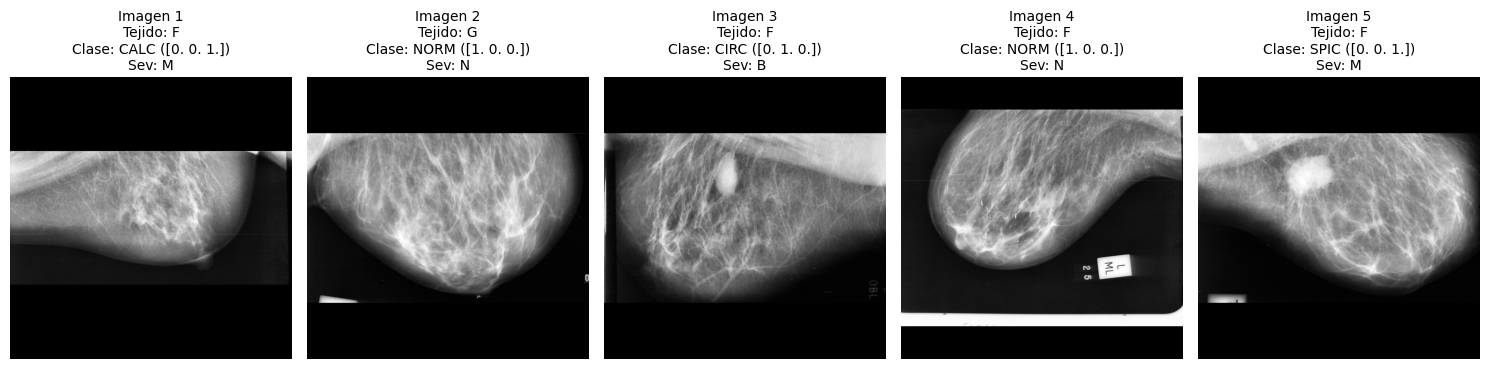

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(15, 6))

for i in range(5):
    axes[i].imshow(X_train[i], cmap='gray')
    
    tejido = df_train.iloc[i]['tejido']
    clase = df_train.iloc[i]['clase']
    severidad = df_train.iloc[i]['severidad']
    label_binario = y_train[i]
    
    titulo = f"Imagen {i+1}\nTejido: {tejido}\nClase: {clase} ({label_binario})\nSev: {severidad}"
    
    axes[i].set_title(titulo, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Data Augmentation

In [8]:
transform_train = A.Compose([
    # Volteo horizontal 
    A.HorizontalFlip(p=0.5),
    
    # Volteo vertical 
    A.VerticalFlip(p=0.2),
    
    # Rotación aleatoria 
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5, border_mode=0),
    
    # Ajuste de contraste y brillo 
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5)
])

def aplicar_data_augmentation(X_set, y_set, num_replicas=1):
    X_aumentado = []
    y_aumentado = []
    
    for i in range(len(X_set)):
        img = X_set[i]
        label = y_set[i]
        X_aumentado.append(img)
        y_aumentado.append(label)
        for _ in range(num_replicas):
            augmented = transform_train(image=img)
            X_aumentado.append(augmented['image'])
            y_aumentado.append(label)
            
    return np.array(X_aumentado), np.array(y_aumentado)
X_train_aug, y_train_aug = aplicar_data_augmentation(X_train, y_train, num_replicas=1)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# Transfer learning

In [9]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dense, Dropout, Add, Lambda, Multiply, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils import class_weight


In [10]:
# =====================================================================
# --- MODELO 1: FCN ESTÁNDAR (Transfer Learning Puro con MobileNetV3) ---
# =====================================================================
print("\n" + "="*50)
print(" CONSTRUYENDO: MODELO FCN ESTÁNDAR (MobileNetV3Large)")
print("="*50)

# 1. Definimos la entrada de tamaño libre (None, None, 1) para escala de grises
inputs_fcn = Input(shape=(None, None, 1), name='input_fcn_estandar')

# 2. Adaptación de canales: Convertimos a 3 canales con una convolución propia
x_fcn = Conv2D(3, (3, 3), padding='same', activation='relu')(inputs_fcn)

# 3. Cargamos el modelo base ligero aceptando tamaño dinámico en 3 canales
# Nota: include_top=False elimina la cabeza densa original de ImageNet
base_model_fcn = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(None, None, 3))
base_model_fcn.trainable = False  # Congelamos para Transfer Learning puro

# 4. Conectamos nuestra capa adaptadora a la entrada del modelo base
x_fcn = base_model_fcn(x_fcn)

# 5. Cabeza de clasificación de la FCN
x_fcn = GlobalAveragePooling2D()(x_fcn)
x_fcn = Dropout(0.3)(x_fcn)

# 3 neuronas de salida con activación Softmax para clasificación multiclase
outputs_fcn = Dense(3, activation='softmax', name='fcn_output')(x_fcn)

# 6. Construimos el modelo final uniendo la entrada original con la salida
model_fcn = Model(inputs=inputs_fcn, outputs=outputs_fcn, name='FCN_MobileNetV3')

# 7. Compilación con función de pérdida para One-Hot-Encoding y métrica AUC multiclase
model_fcn.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model_fcn.summary()


 CONSTRUYENDO: MODELO FCN ESTÁNDAR (MobileNetV3Large)


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "FCN_MobileNetV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_fcn_estandar (InputLayer) │ (None, None, None, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, None, None, 3)  │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, None, None,     │     2,996,352 │
│                                 │ 960)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fcn_output (Dense)              │ (None, 3)              │         2,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999,265 (11.44 MB)

 Trainable params: 2,913 (11.38 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [11]:
# =====================================================================
# --- MODELO 2: FCN CON MIXTURE OF EXPERTS (MoE con MobileNetV3) ---
# =====================================================================
print("\n" + "="*50)
print(" CONSTRUYENDO: MODELO FCN + MIXTURE OF EXPERTS (MobileNetV3Large)")
print("="*50)

# 1. Entrada de tamaño libre y adaptación de canales
inputs_moe = Input(shape=(None, None, 1), name='input_fcn_moe')
x_moe = Conv2D(3, (3, 3), padding='same', activation='relu')(inputs_moe)

# 2. Extractor de características común (Base Compartida con MobileNetV3)
base_model_moe = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(None, None, 3))
base_model_moe.trainable = False 
features_moe = base_model_moe(x_moe)

# 3. Reducción espacial manteniendo tamaño libre para la toma de decisiones
shared_vector = GlobalAveragePooling2D()(features_moe)
shared_vector = Dropout(0.3)(shared_vector)

# --- IMPLEMENTACIÓN DE MIXTURE OF EXPERTS (MoE) ---

# GATING NETWORK (El Enrutador)
gate_weights = Dense(3, activation='softmax', name='gating_network')(shared_vector)

# EXPERTO 1: Especializado en texturas finas (Microcalcificaciones / Asimetrías)
expert_1 = Dense(128, activation='relu')(shared_vector)
expert_1_out = Dense(3, activation='softmax', name='expert_calcificaciones')(expert_1)

# EXPERTO 2: Especializado en masas densas y distorsiones arquitectónicas
expert_2 = Dense(128, activation='relu')(shared_vector)
expert_2_out = Dense(3, activation='softmax', name='expert_masas')(expert_2)

# EXPERTO 3: Experto genérico (Patrón de tejido normal o variaciones generales)
expert_3 = Dense(128, activation='relu')(shared_vector)
expert_3_out = Dense(3, activation='softmax', name='expert_general')(expert_3)

# Extracción y expansión de dimensiones simbólicas para ponderar a los expertos
g1 = Lambda(lambda g: tf.expand_dims(g[:, 0], axis=-1), name='weight_expert_1')(gate_weights)
g2 = Lambda(lambda g: tf.expand_dims(g[:, 1], axis=-1), name='weight_expert_2')(gate_weights)
g3 = Lambda(lambda g: tf.expand_dims(g[:, 2], axis=-1), name='weight_expert_3')(gate_weights)

# Ponderación: Multiplicamos las predicciones de cada experto por la decisión de su compuerta
w_expert1 = Multiply()([expert_1_out, g1])
w_expert2 = Multiply()([expert_2_out, g2])
w_expert3 = Multiply()([expert_3_out, g3])

# Combinación final: Suma ponderada de las opiniones de los expertos
outputs_moe = Add(name='moe_output')([w_expert1, w_expert2, w_expert3])

# 4. Construcción y compilación de la FCN con MoE integrado
model_fcn_moe = Model(inputs=inputs_moe, outputs=outputs_moe, name='FCN_MoE_MobileNetV3')

model_fcn_moe.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model_fcn_moe.summary()


 CONSTRUYENDO: MODELO FCN + MIXTURE OF EXPERTS (MobileNetV3Large)


Model: "FCN_MoE_MobileNetV3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_fcn_moe       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │         30 │ input_fcn_moe[0]… │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, None,      │  2,996,352 │ conv2d_1[0][0]    │
│ (Functional)        │ None, 960)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    123,008 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gating_network      │ (None, 3)         │      2,883 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    123,008 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    123,008 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_calcificaci… │ (None, 3)         │        387 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weight_expert_1     │ (None, 1)         │          0 │ gating_network[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_masas        │ (None, 3)         │        387 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weight_expert_2     │ (None, 1)         │          0 │ gating_network[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_general      │ (None, 3)         │        387 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weight_expert_3     │ (None, 1)         │          0 │ gating_network[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 3)         │          0 │ expert_calcifica… │
│ (Multiply)          │                   │            │ weight_expert_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_17         │ (None, 3)         │          0 │ expert_masas[0][… │
│ (Multiply)          │                   │            │ weight_expert_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_18         │ (None, 3)         │          0 │ expert_general[0… │
│ (Multiply)          │                   │            │ weight_expert_3[

 Total params: 3,369,450 (12.85 MB)

 Trainable params: 373,098 (1.42 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [12]:
# =====================================================================
# --- MODELO 2: CNN ALTERNATIVA (Transfer Learning Puro con EfficientNetB0) ---
# =====================================================================
print("\n" + "="*50)
print(" CONSTRUYENDO: MODELO CNN ALTERNATIVO (EfficientNetB0)")
print("="*50)

# 1. Definimos la entrada de tamaño libre (None, None, 1) para escala de grises
inputs_cnn = Input(shape=(None, None, 1), name='input_cnn_alternativo')

# 2. Adaptación de canales: Convertimos a 3 canales con una convolución propia
x_cnn = Conv2D(3, (3, 3), padding='same', activation='relu')(inputs_cnn)

# 3. Cargamos el modelo base ligero aceptando tamaño dinámico en 3 canales
# Nota: include_top=False elimina la cabeza densa original de ImageNet
base_model_cnn = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(None, None, 3))
base_model_cnn.trainable = False  # Congelamos para Transfer Learning puro

# 4. Conectamos nuestra capa adaptadora a la entrada del modelo base
x_cnn = base_model_cnn(x_cnn)

# 5. Cabeza de clasificación de la CNN
x_cnn = GlobalAveragePooling2D()(x_cnn)
x_cnn = Dropout(0.3)(x_cnn)

# 3 neuronas de salida con activación Softmax para clasificación multiclase
outputs_cnn = Dense(3, activation='softmax', name='cnn_output')(x_cnn)

# 6. Construimos el modelo final uniendo la entrada original con la salida
model_cnn = Model(inputs=inputs_cnn, outputs=outputs_cnn, name='CNN_EfficientNetB0')

# 7. Compilación con función de pérdida para One-Hot-Encoding y métrica AUC multiclase
model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model_cnn.summary()


 CONSTRUYENDO: MODELO CNN ALTERNATIVO (EfficientNetB0)


Model: "CNN_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_cnn_alternativo           │ (None, None, None, 1)  │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, None, None, 3)  │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_output (Dense)              │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,444 (15.46 MB)

 Trainable params: 3,873 (15.13 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
# --- Preprocesamiento y Asignaciones (Verificado) ---
X_train_final = np.expand_dims(X_train_aug.astype(np.float32) , axis=-1)
X_val_final = np.expand_dims(X_val.astype(np.float32) , axis=-1)
X_test_final = np.expand_dims(X_test.astype(np.float32) , axis=-1)

y_train_final_3c = y_train_aug

# --- 1. CONFIGURACIÓN DE PARÁMETROS DE ENTRENAMIENTO ---
BATCH_SIZE = 3  # Ajustado para balancear velocidad y VRAM
EPOCHS = 25      

def obtener_callbacks(nombre_modelo):
    """Genera los callbacks de control para cada experimento de forma independiente"""
    return [
        EarlyStopping(
            monitor='val_loss', 
            patience=2, 
            restore_best_weights=True, 
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'mejor_{nombre_modelo}.keras', 
            monitor='val_loss', 
            save_best_only=True, 
            verbose=1
        )
    ]

In [14]:
print("\n" + "="*50)
print(" INICIANDO ENTRENAMIENTO: MODELO FCN ESTÁNDAR")
print("="*50)

history_fcn = model_fcn.fit(
    X_train_final, y_train_final_3c,       
    validation_data=(X_val_final, y_val),  
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_fcn'),
    verbose=1
)


print("\n--- Evaluando FCN Estándar en Test ---")
test_loss_fcn, test_acc_fcn, test_auc_fcn = model_fcn.evaluate(
    X_test_final, y_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)
print(f"FCN Estándar -> Pérdida: {test_loss_fcn:.4f} | Precisión: {test_acc_fcn:.4f} | AUC: {test_auc_fcn:.4f}")


 INICIANDO ENTRENAMIENTO: MODELO FCN ESTÁNDAR
Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4751 - auc: 0.4473 - loss: 1.0551
Epoch 1: val_loss improved from None to 0.96152, saving model to mejor_model_fcn.keras

Epoch 1: finished saving model to mejor_model_fcn.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.5178 - auc: 0.4643 - loss: 1.0262 - val_accuracy: 0.6042 - val_auc: 0.4971 - val_loss: 0.9615
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6474 - auc: 0.5215 - loss: 0.8992
Epoch 2: val_loss improved from 0.96152 to 0.94583, saving model to mejor_model_fcn.keras

Epoch 2: finished saving model to mejor_model_fcn.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.6178 - auc: 0.5052 - loss: 0.9437 - val_accuracy: 0.6042 - val_auc: 0.4648 - val_loss: 0.9458
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5759 - auc: 0.4692 - loss: 0.9803
Epoch 3: val_loss did not improve from 0.94583
150/150 ━

In [ ]:
print("\n" + "="*50)
print(" INICIANDO ENTRENAMIENTO: MODELO FCN + MoE")
print("="*50)

history_moe = model_fcn_moe.fit(
    X_train_final, y_train_final_3c,       
    validation_data=(X_val_final, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_fcn_moe'),
    verbose=1
)

print("\n--- Evaluando FCN con MoE en Test ---")
test_loss_moe, test_acc_moe, test_auc_moe = model_fcn_moe.evaluate(
    X_test_final, y_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)
print(f"FCN con MoE   -> Pérdida: {test_loss_moe:.4f} | Precisión: {test_acc_moe:.4f} | AUC: {test_auc_moe:.4f}")


 INICIANDO ENTRENAMIENTO: MODELO FCN + MoE
Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6512 - auc: 0.4756 - loss: 0.9253
Epoch 1: val_loss improved from None to 0.94985, saving model to mejor_model_fcn_moe.keras

Epoch 1: finished saving model to mejor_model_fcn_moe.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 44s 149ms/step - accuracy: 0.6444 - auc: 0.4864 - loss: 0.9229 - val_accuracy: 0.6042 - val_auc: 0.5000 - val_loss: 0.9498
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6024 - auc: 0.5475 - loss: 0.9447
Epoch 2: val_loss did not improve from 0.94985
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.6444 - auc: 0.5600 - loss: 0.8912 - val_accuracy: 0.6042 - val_auc: 0.5000 - val_loss: 0.9540
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6261 - auc: 0.4981 - loss: 0.9339
Epoch 3: val_loss did not improve from 0.94985
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.6444 - auc: 0.4838 - loss: 0.9094 - val_accurac

: 

In [16]:
print("\n" + "="*50)
print(" INICIANDO ENTRENAMIENTO: MODELO CNN ALTERNATIVO")
print("="*50)

history_cnn = model_cnn.fit(
    X_train_final, y_train_final_3c,       
    validation_data=(X_val_final, y_val),  
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_cnn'),
    verbose=1
)


print("\n--- Evaluando CNN Alternativo en Test ---")
test_loss_cnn, test_acc_cnn, test_auc_cnn = model_cnn.evaluate(
    X_test_final, y_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)
print(f"CNN Alternativo -> Pérdida: {test_loss_cnn:.4f} | Precisión: {test_acc_cnn:.4f} | AUC: {test_auc_cnn:.4f}")


 INICIANDO ENTRENAMIENTO: MODELO CNN ALTERNATIVO


: 

: 

NameError: name 'history_cnn' is not defined

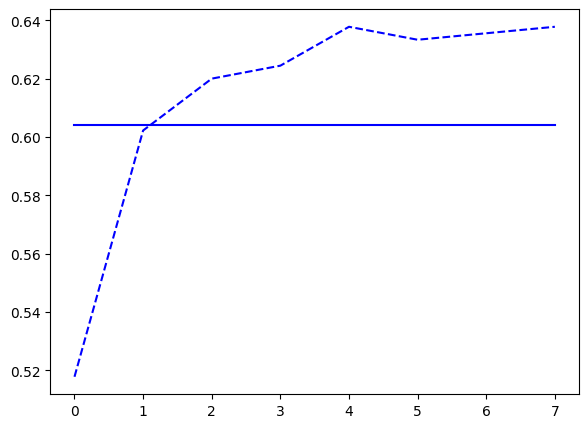

In [ ]:
plt.figure(figsize=(15, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_fcn.history['accuracy'], label='FCN Train Acc', linestyle='--', color='blue')
plt.plot(history_fcn.history['val_accuracy'], label='FCN Val Acc', color='blue')
plt.plot(history_cnn.history['accuracy'], label='CNN Train Acc', linestyle='--', color='green')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc', color='green')
plt.plot(history_moe.history['accuracy'], label='MoE Train Acc', linestyle='--', color='orange')
plt.plot(history_moe.history['val_accuracy'], label='MoE Val Acc', color='orange')
plt.title('Comparativa de Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_fcn.history['loss'], label='FCN Train Loss', linestyle='--', color='blue')
plt.plot(history_fcn.history['val_loss'], label='FCN Val Loss', color='blue')
plt.plot(history_cnn.history['loss'], label='CNN Train Loss', linestyle='--', color='green')
plt.plot(history_cnn.history['val_loss'], label='CNN Val Loss', color='green')
plt.plot(history_moe.history['loss'], label='MoE Train Loss', linestyle='--', color='orange')
plt.plot(history_moe.history['val_loss'], label='MoE Val Loss', color='orange')
plt.title('Comparativa de Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()